<a href="https://colab.research.google.com/github/meenakshis3019/Cisco-packet-tracer-LAN-Connection/blob/main/COSMAEGIS_01_Data_Collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install skyfield pandas numpy matplotlib requests -q

print("All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 15.4 MB/s eta 0:00:00
All libraries installed successfully!


In [2]:

from skyfield.api import load, EarthSatellite
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

print("All imports successful!")
print("COSMAEGIS is ready to launch!")

All imports successful!
COSMAEGIS is ready to launch!


In [4]:


USERNAME = "meenakshis3019@gmail.com"
PASSWORD = "8tk_edb9SkCH3C*"

BASE_URL = "https://www.space-track.org"

session = requests.Session()

login_data = {
    "identity": USERNAME,
    "password": PASSWORD
}

login_response = session.post(
    f"{BASE_URL}/ajaxauth/login",
    data=login_data
)

if login_response.status_code == 200:
    print("Login successful!")
else:
    print("Login failed — check your username and password")

Login successful!


In [6]:

tle_url = (
    f"{BASE_URL}/basicspacedata/query/"
    f"class/gp/OBJECT_TYPE/DEBRIS/"
    f"orderby/NORAD_CAT_ID/format/tle"
)

response = session.get(tle_url)

if response.status_code == 200:
    tle_data = response.text

    with open("tle_debris.txt", "w") as f:
        f.write(tle_data)

    lines = [l for l in tle_data.strip().split("\n") if l.strip()]
    print(f"Download successful!")
    print(f"Total debris objects: {len(lines)//2}")
    print(f"Preview:")
    print("\n".join(lines[:6]))
else:
    print(f"Status code: {response.status_code}")
    print(f"Error message: {response.text[:200]}")

Download successful!
Total debris objects: 34370
Preview:
1 00033U 60003  C 60280.33271408  .00001932 +00000-0 +00000-0 0  9994
2 00033 051.2879 136.0668 0242757 196.7800 163.6100 15.38343354027003
1 00037U 60005  D 61074.65882873  .00039007 +00000-0 +00000-0 0  9995
2 00037 064.8899 343.2411 0198403 333.4201 027.0840 15.49800338046906
1 00038U 60005  E 60232.69066809  .00610805 +00000-0 +00000-0 0  9999
2 00038 064.8899 302.1218 0034213 049.4823 310.6691 15.88909013015003


In [7]:

ts = load.timescale()
t = ts.now()

debris_list = []
lines = tle_data.strip().split("\n")

for i in range(0, len(lines)-1, 2):
    try:
        line1 = lines[i].strip()
        line2 = lines[i+1].strip()

        sat = EarthSatellite(line1, line2, ts=ts)
        pos = sat.at(t).position.km
        vel = sat.at(t).velocity.km_per_s

        debris_list.append({
            'id': i//2,
            'x_km': round(pos[0], 2),
            'y_km': round(pos[1], 2),
            'z_km': round(pos[2], 2),
            'vx': round(vel[0], 4),
            'vy': round(vel[1], 4),
            'vz': round(vel[2], 4),
            'altitude_km': round(
                (pos[0]**2 + pos[1]**2 + pos[2]**2)**0.5 - 6371, 2
            )
        })
    except Exception as e:
        pass

df = pd.DataFrame(debris_list)
print(f"Total debris objects parsed: {len(df)}")
print(f"\nFirst 10 debris objects:")
print(df.head(10))

Total debris objects parsed: 34370

First 10 debris objects:
   id     x_km     y_km     z_km      vx      vy      vz  altitude_km
0   0  2323.79 -3828.64  5326.52  6.8858  2.7038 -1.1918       588.19
1   1 -1461.64  2852.96  5831.70 -4.6061 -6.0444  1.8203       283.66
2   2   413.23  6269.35  2226.62 -3.3459  2.5249 -6.5134       294.84
3   3 -3866.03  2487.68  4923.85 -6.2751 -1.6364 -4.0955       365.39
4   4  4345.08  3262.24  4014.31  0.5863  5.5309 -5.2990       384.49
5   5   861.37  2744.37 -6022.54 -6.8560  3.5218  0.6003       303.16
6   6  6111.85  -277.01 -2947.58 -2.7935  3.7122 -6.0382       420.14
7   7  6267.72  1008.95  1814.59 -2.1135  6.5316  3.6498       231.66
8   8  7178.10 -1027.15  3317.42  2.7561  4.9463 -4.2385      1603.05
9   9  2381.31  7169.91  4334.22 -5.5326 -0.7833  3.1596      2338.98


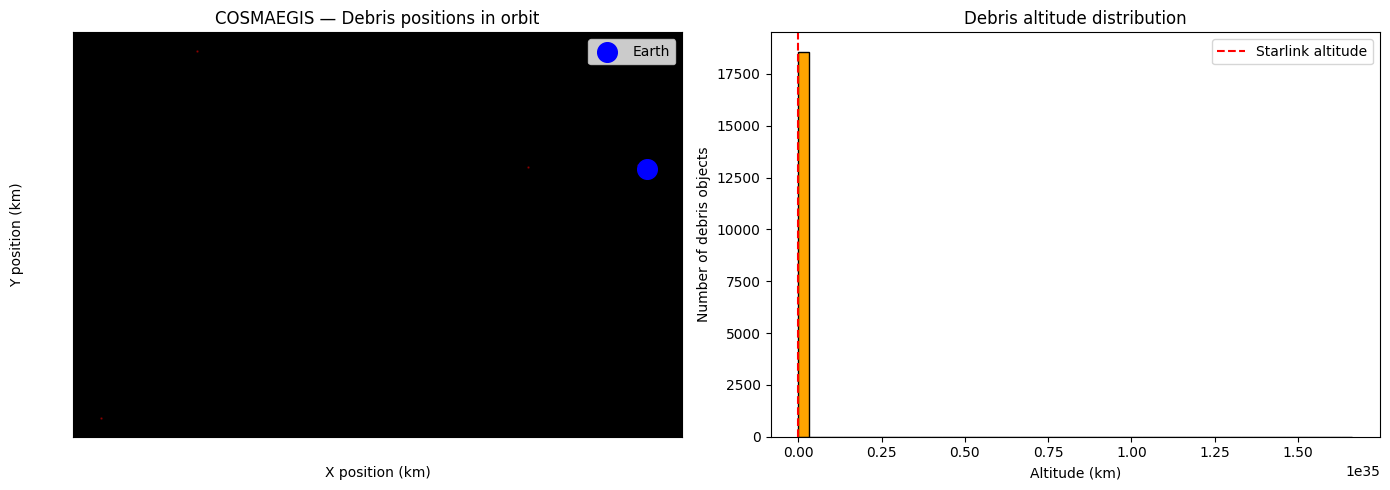

Debris map saved!


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(df['x_km'], df['y_km'],
                s=0.5, alpha=0.4, color='red')
axes[0].scatter(0, 0, s=200, color='blue',
                label='Earth', zorder=5)
axes[0].set_title('COSMAEGIS — Debris positions in orbit')
axes[0].set_xlabel('X position (km)')
axes[0].set_ylabel('Y position (km)')
axes[0].legend()
axes[0].set_facecolor('black')
axes[0].tick_params(colors='white')

axes[1].hist(df['altitude_km'], bins=50,
             color='orange', edgecolor='black')
axes[1].set_title('Debris altitude distribution')
axes[1].set_xlabel('Altitude (km)')
axes[1].set_ylabel('Number of debris objects')
axes[1].axvline(x=550, color='red',
                linestyle='--', label='Starlink altitude')
axes[1].legend()

plt.tight_layout()
plt.savefig('cosmaegis_debris_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Debris map saved!")

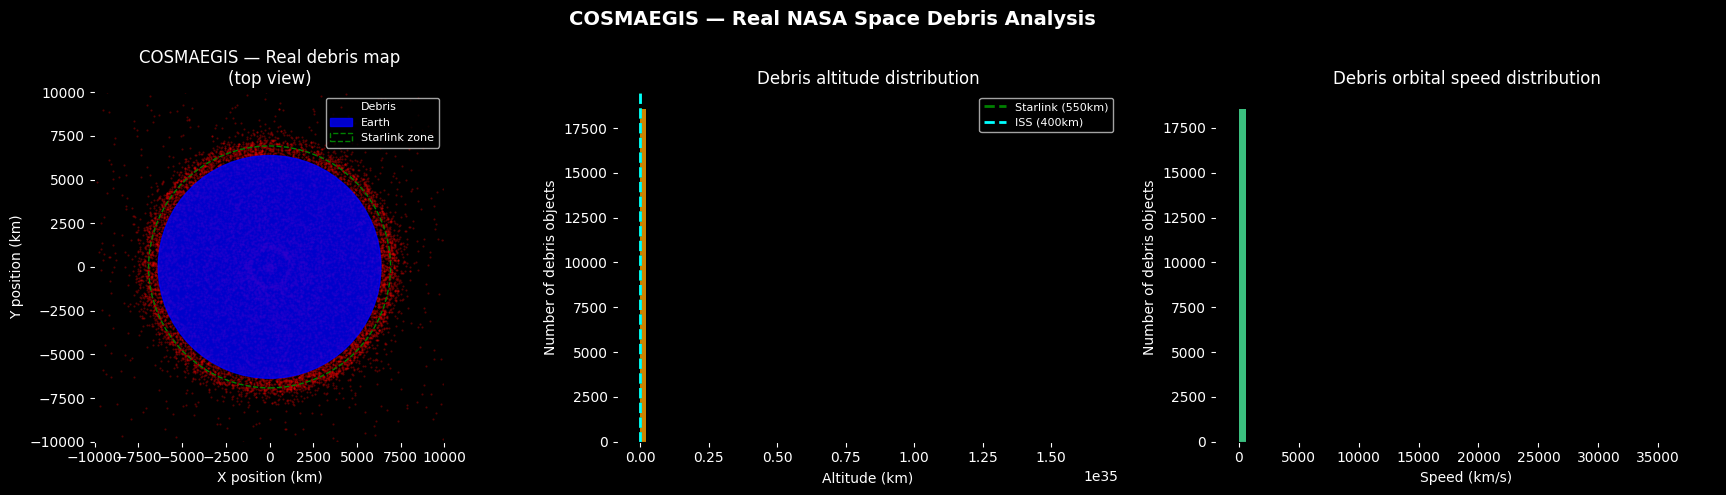

Visualization saved!


In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('black')


axes[0].set_facecolor('black')
axes[0].scatter(df['x_km'], df['y_km'],
                s=0.3, alpha=0.3, color='red', label='Debris')


earth = plt.Circle((0,0), 6371, color='blue',
                    alpha=0.8, label='Earth')
axes[0].add_patch(earth)

starlink = plt.Circle((0,0), 6371+550,
                       color='green', fill=False,
                       linestyle='--',
                       linewidth=1, label='Starlink zone')
axes[0].add_patch(starlink)

axes[0].set_xlim(-10000, 10000)
axes[0].set_ylim(-10000, 10000)
axes[0].set_aspect('equal')
axes[0].set_title('COSMAEGIS — Real debris map\n(top view)',
                   color='white', fontsize=12)
axes[0].set_xlabel('X position (km)', color='white')
axes[0].set_ylabel('Y position (km)', color='white')
axes[0].tick_params(colors='white')
axes[0].legend(loc='upper right', fontsize=8,
               facecolor='black', labelcolor='white')


axes[1].set_facecolor('black')
axes[1].hist(df['altitude_km'], bins=80,
             color='orange', edgecolor='none', alpha=0.8)
axes[1].axvline(x=550, color='green', linestyle='--',
                linewidth=2, label='Starlink (550km)')
axes[1].axvline(x=400, color='cyan', linestyle='--',
                linewidth=2, label='ISS (400km)')
axes[1].set_title('Debris altitude distribution',
                   color='white', fontsize=12)
axes[1].set_xlabel('Altitude (km)', color='white')
axes[1].set_ylabel('Number of debris objects', color='white')
axes[1].tick_params(colors='white')
axes[1].legend(fontsize=8, facecolor='black',
               labelcolor='white')


speed = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)
axes[2].set_facecolor('black')
axes[2].hist(speed, bins=60, color='#4af0a0',
             edgecolor='none', alpha=0.8)
axes[2].set_title('Debris orbital speed distribution',
                   color='white', fontsize=12)
axes[2].set_xlabel('Speed (km/s)', color='white')
axes[2].set_ylabel('Number of debris objects', color='white')
axes[2].tick_params(colors='white')

plt.suptitle('COSMAEGIS — Real NASA Space Debris Analysis',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cosmaegis_debris_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor='black')
plt.show()
print("Visualization saved!")

In [10]:

df.to_csv('cosmaegis_debris_clean.csv', index=False)
print(f"Clean dataset saved!")
print(f"Total debris objects: {len(df)}")
print(f"\nKey statistics:")
print(f"Average altitude: {df['altitude_km'].mean():.1f} km")
print(f"Min altitude: {df['altitude_km'].min():.1f} km")
print(f"Max altitude: {df['altitude_km'].max():.1f} km")
print(f"Debris in Starlink zone (400-600km): "
      f"{len(df[df['altitude_km'].between(400,600)])}")
print(f"Debris near ISS (350-450km): "
      f"{len(df[df['altitude_km'].between(350,450)])}")

Clean dataset saved!
Total debris objects: 34370

Key statistics:
Average altitude: 19885588333030350119485734649856.0 km
Min altitude: -6170.4 km
Max altitude: 166314360577994821154323608650121216.0 km
Debris in Starlink zone (400-600km): 1148
Debris near ISS (350-450km): 637


In [11]:

df_clean = df[
    (df['altitude_km'] >= 150) &
    (df['altitude_km'] <= 50000)
].copy()


df_clean = df_clean.reset_index(drop=True)

df_clean.to_csv('cosmaegis_debris_clean.csv', index=False)

print(f"Original dataset: {len(df)} objects")
print(f"After cleaning: {len(df_clean)} objects")
print(f"Bad records removed: {len(df) - len(df_clean)}")
print(f"\nKey statistics:")
print(f"Average altitude: {df_clean['altitude_km'].mean():.1f} km")
print(f"Min altitude: {df_clean['altitude_km'].min():.1f} km")
print(f"Max altitude: {df_clean['altitude_km'].max():.1f} km")
print(f"Debris in Starlink zone (400-600km): "
      f"{len(df_clean[df_clean['altitude_km'].between(400,600)])}")
print(f"Debris near ISS (350-450km): "
      f"{len(df_clean[df_clean['altitude_km'].between(350,450)])}")

Original dataset: 34370 objects
After cleaning: 16149 objects
Bad records removed: 18221

Key statistics:
Average altitude: 3460.6 km
Min altitude: 150.2 km
Max altitude: 49538.9 km
Debris in Starlink zone (400-600km): 1148
Debris near ISS (350-450km): 637


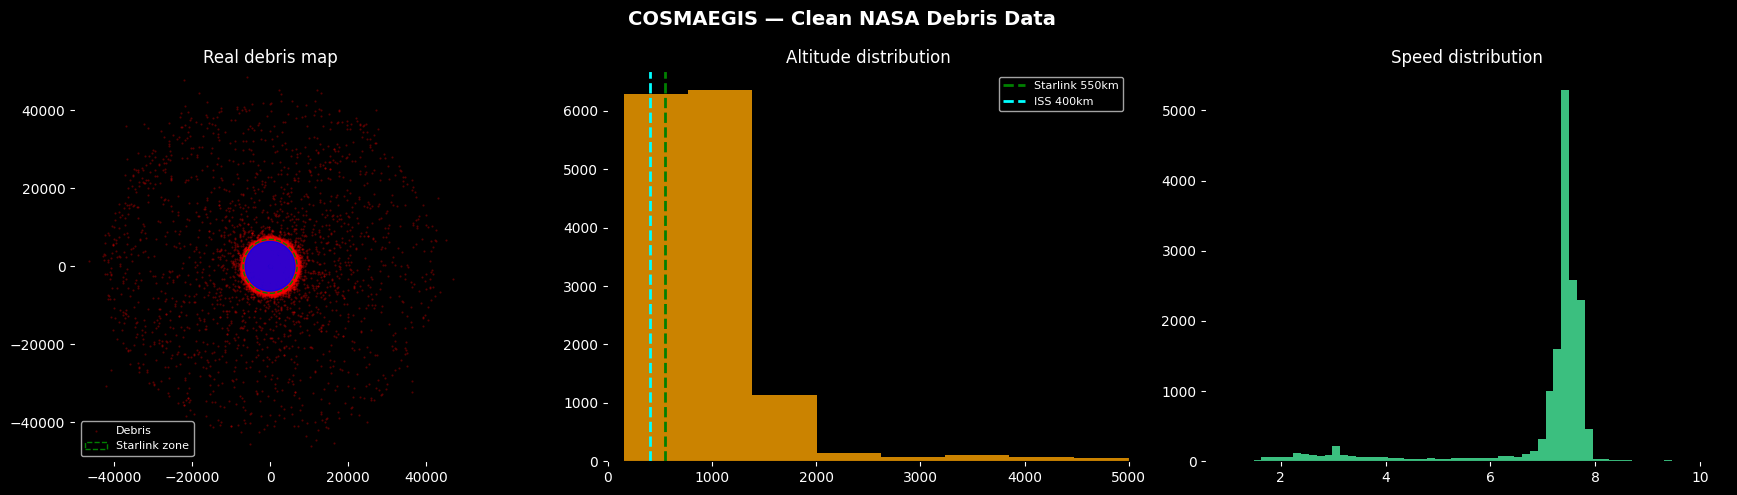

Clean visualization saved!


In [12]:

df = df_clean.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('black')

axes[0].set_facecolor('black')
axes[0].scatter(df['x_km'], df['y_km'],
                s=0.3, alpha=0.3,
                color='red', label='Debris')
earth = plt.Circle((0,0), 6371,
                    color='blue', alpha=0.8)
axes[0].add_patch(earth)
starlink = plt.Circle((0,0), 6371+550,
                       color='green', fill=False,
                       linestyle='--', linewidth=1,
                       label='Starlink zone')
axes[0].add_patch(starlink)
axes[0].set_xlim(-50000, 50000)
axes[0].set_ylim(-50000, 50000)
axes[0].set_aspect('equal')
axes[0].set_title('Real debris map',
                   color='white')
axes[0].tick_params(colors='white')
axes[0].legend(facecolor='black',
               labelcolor='white', fontsize=8)

axes[1].set_facecolor('black')
axes[1].hist(df['altitude_km'], bins=80,
             color='orange', alpha=0.8)
axes[1].axvline(x=550, color='green',
                linestyle='--', linewidth=2,
                label='Starlink 550km')
axes[1].axvline(x=400, color='cyan',
                linestyle='--', linewidth=2,
                label='ISS 400km')
axes[1].set_xlim(0, 5000)
axes[1].set_title('Altitude distribution',
                   color='white')
axes[1].tick_params(colors='white')
axes[1].legend(facecolor='black',
               labelcolor='white', fontsize=8)


import numpy as np
speed = np.sqrt(df['vx']**2 +
                df['vy']**2 +
                df['vz']**2)
axes[2].set_facecolor('black')
axes[2].hist(speed, bins=60,
             color='#4af0a0', alpha=0.8)
axes[2].set_title('Speed distribution',
                   color='white')
axes[2].tick_params(colors='white')

plt.suptitle('COSMAEGIS — Clean NASA Debris Data',
             color='white', fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.savefig('cosmaegis_clean_analysis.png',
            dpi=150, bbox_inches='tight',
            facecolor='black')
plt.show()
print("Clean visualization saved!")

In [13]:

from google.colab import files
files.download('cosmaegis_debris_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>